# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 8</span>
### <span style= "color: black" > Es08.1


Lo scopo di questo esercizio è applicare il metodo del *Variational Monte Carlo* (VMC) ad una particella quantistica unidimensionale soggetta a potenziale $V(x) = x^4 - \frac{5}{2}x^2$ ed il cui stato fondamentale (*ground state*) è approssimato dalla seguente funzione d'onda 
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$ 

dove $(\mu, \sigma)$ sono i parametri variazionali.

In particolare si vuole campionare $|\Psi_T^{\sigma,\mu}(x)|^2$ a $(\mu, \sigma)$ fissati usando l'algoritmo di Metropolis con una probabilità di transizione $T(x_{new}|x_{old})$ uniforme. In questo modo, usando il metodo del data blocking, è possibile ricavare il valore di aspettazione dell'energia a temperatura $T$ tramite la seguente espressione: 
$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)} = {\int dx p(x) E_{loc}(x)}
$$

dove $p(x) = \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2}$ e $E_{loc}(x) = \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}$.

Nel codice da implementare è necessario calcolare analiticamente $\hat H$ $\Psi_T^{\sigma,\mu}(x)$, ovvero $V(x)\Psi_T^{\sigma,\mu}(x)$ - $\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} \Psi_T^{\sigma,\mu}(x)$, considerando $\hbar = 1$ and $m=1$.

In questo caso i parametri variazionali vengono fissati a ($\mu, \sigma) = (1, 0.5)$ e, utilizzando una probabilità di transizione uniforme, il nuovo punto viene estratto nel seguente modo: 
$$
x_{\text{new}} \sim U\left(x_{\text{old}}-\frac{\delta}{2}, x_{\text{old}}+\frac{\delta}{2}\right),
$$ 

con $\delta = 2.5$ per mantenere un accettazione per blocco intorno al $50\%$. 

La simulazione viene eseguita con $N=500$ blocchi statistici da $L=2000$ steps per blocco, per un totale di $M = 10^6$ steps Monte Carlo. Prima di eseguire la simulazione il sistema viene equilibrato per $20000$ steps Monte Carlo.

A titolo di esempio, qui di seguito viene mostrato l'andamento della media progressiva di $\langle {\hat H} \rangle_T$ con il suo errore statistico in funzione del numero di blocchi.

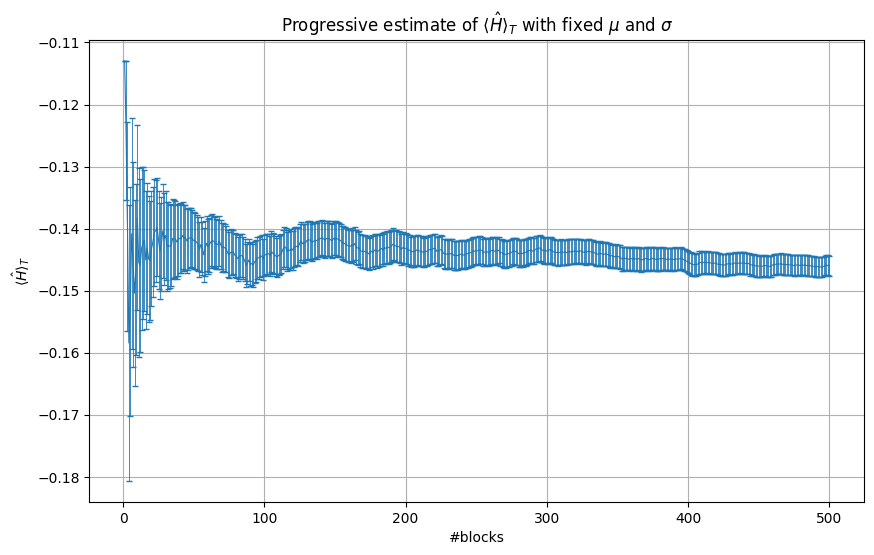

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Plot progressive estimates and their statistical uncertainties
def plot (filename, x_name, y_name, title, color, linewidth):
    plt.figure(figsize=(10, 6))

    # Load block index, progressive average and statistical error
    x,y, error = np.loadtxt(filename, usecols=(0,1,2), unpack=True)

    # Plot the progressive estimate with error bars
    plt.errorbar(x,y,yerr=error, fmt='-',linewidth=linewidth, elinewidth=0.6,capsize=2, color = color)
    plt.xlabel(x_name) 
    plt.ylabel(y_name)
    plt.title(title)
    plt.grid(True)
    plt.show()

# Show the VMC estimate obtained with fixed variational parameters
plot("Output/output8.1.txt", '#blocks', r'$\langle \hat{H} \rangle_T$', r'Progressive estimate of $\langle \hat{H} \rangle_T$ with fixed $\mu$ and $\sigma$', "C0", 0.8)


### <span style= "color: black" > Es08.2

In meccanica quantistica il principio variazionale afferma che la stima del valore di aspettazione dell'hamiltoniana $H$ di un sistema quantistico calcolata usando una funzione d'onda $\Psi_T^{\sigma,\mu}(x)$, è sempre maggiore (o uguale) della stima che si ottiene se si utilizzasse la funzione d'onda dello stato fondamentale $\Psi_0^{\sigma,\mu}(x)$ (l'uguaglianza vale se $T=0$):

$$
\langle {\hat H} \rangle_T = 
\frac{\langle \Psi_T| {\hat H} | \Psi_T \rangle}
{\langle \Psi_T | \Psi_T \rangle} = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}.
$$

Lo scopo di questo esercizio è utilizzare la tecnica del *Simulated Annealing* (SA) per determinare i parametri variazionali $(\mu,\sigma)$ che minimizzano il valore di aspettazione dell’energia $\langle \hat{H} \rangle_T$, fornendo così la migliore stima variazionale dell’energia dello stato fondamentale (*ground state*).

Il *Simulated Annealing* nasce da un’analogia con i processi termodinamici di raffreddamento, come la cristallizzazione di un liquido. Se il sistema viene raffreddato troppo rapidamente, può rimanere intrappolato in una configurazione metastabile.
Al contrario, un raffreddamento sufficientemente lento permette al sistema di esplorare un numero maggiore di configurazioni e aumenta la probabilità di raggiungere lo stato di energia minima.

Nel problema considerato, il ruolo della configurazione del sistema è svolto dalla coppia di parametri variazionali $(\mu,\sigma)$, mentre la funzione da minimizzare è l’energia variazionale $\langle \hat{H} \rangle_T$.

Nella simulazione si procede nel seguente modo:

1. Si sceglie un valore iniziale dell’inverso della temperatura, $\beta = \frac{1}{T} = 1$, e si utilizza la legge di aggiornamento             $\beta = \beta*1.05$. In questo modo $\beta$ aumenta progressivamente e la temperatura $T=1/\beta$ diminuisce. Si parte da una temperatura *alta* e si prosegue *raffreddando* il sistema perché così configurazioni **anche** energeticamente peggiori hanno più probabilità di essere accettate e questo permette di esplorare più ampiamente lo spazio dei parametri $(\mu,\sigma)$ ed evitare di rimanere intrappolati in minimi locali.

2. Si parte dalla coppia di parametri variazionali $(\mu,\sigma)=(1,0.5)$, corrispondente ai valori utilizzati nell’esercizio `08.1`. La posizione $x$ e l'energia di partenza saranno quind anch'essi quelli ricavati dall'esercizio precedente.

3. Per ogni valore di $\beta$ vengono proposte $10$ nuove coppie di parametri $(\mu_{new},\sigma_{new})$, estraendole da distribuzioni uniformi centrate sui valori correnti $(\mu,\sigma)$. 

    In particolare $\mu_{\text{new}} \sim U\left(\mu_{\text{old}}-\delta_{\mu}, \mu_{\text{old}}+\delta_{\mu}\right)$ con $\delta_{\mu} = 0.3$ e $\sigma_{\text{new}} \sim U\left(\sigma_{\text{old}}-\delta_{\sigma}, \sigma_{\text{old}}+\delta_{\sigma}\right)$ con $\delta_{\sigma} = 0.1$.

4. Per ogni nuova coppia $(\mu_{new},\sigma_{new})$ viene equilibrato il sistema per $1000$ steps Monte Carlo, dopodiché viene eseguita una simulazione di Variational Monte Carlo tramite la quale si stima il valore dell’energia $E_{\mathrm{new}}=\langle \hat{H}\rangle_T$.

5. La nuova configurazione viene accettata secondo la probabilità di Metropolis del Simulated Annealing:

   $$
   \alpha =
   \min\left[
   1,
   e^{-\beta(E_{\mathrm{new}}-E_{\mathrm{old}})}
   \right].
   $$

   Se $E_{\mathrm{new}}<E_{\mathrm{old}}$, la nuova coppia viene sempre accettata. Se invece l’energia aumenta, la nuova configurazione può comunque essere accettata con una probabilità che diminuisce all’aumentare di $\beta$.

6. Tramite il raffreddamento la simulazione tende a concentrarsi attorno alla regione dello spazio dei parametri che minimizza $\langle \hat{H}\rangle_T$. Il procedimento viene arrestato quando la differenza tra due valori consecutivi di energia, $\mu$ e $\sigma$ risultano $<0.01$ per $5$ iterazioni consecutive, oppure quando viene raggiunto il numero massimo di cicli previsto impostato a $150$ (si aggiunge questo ulteriore controllo per evitare che il ciclo *do while* utilizzato continui all'infinito).


Qui di seguito viene mostrato l'andamento di $\langle {\hat H} \rangle_T$ con il suo errore statistico in funzione degli step dell'algoritmo SA.
Si può notare la convergenza di $\langle {\hat H} \rangle_T$ a poco più di $120$ steps stando quindi ad indicare che si è raggiunta per $5$ steps consecutivi la precisione richiesta.

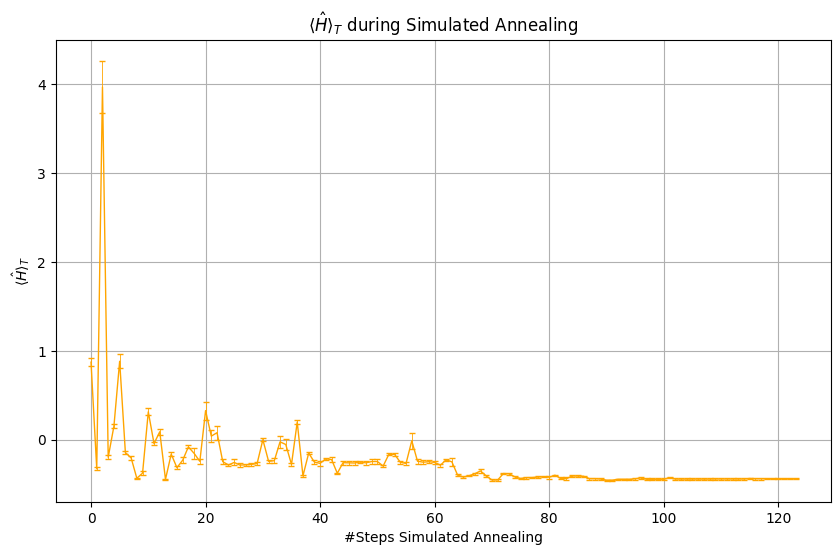

<H>_0 = -0.438262 ± 0.008272
Optimized Parameters:
mu = -0.802794
sigma = 0.626205


In [3]:
# Plot the energy estimate during the Simulated Annealing optimization
plot("Output/risultati_SA.txt", '#Steps Simulated Annealing', r'$\langle \hat{H} \rangle_T$', r'$\langle \hat{H} \rangle_T$ during Simulated Annealing', "orange", 1)

# Load energy, its uncertainty and the corresponding variational parameters
E, errore, mu, sigma = np.loadtxt("Output/risultati_SA.txt", usecols= (1,2,3,4), unpack= True)

# Print the final energy estimate and the optimized values of mu and sigma
print(f"<H>_0 = {E[-1]:.6f} ± {errore[-1]:.6f}\n" "Optimized Parameters:\n" f"mu = {mu[-1]:.6f}\n" f"sigma = {sigma[-1]:.6f}")


Si mostra ora anche la traiettoria dell'algoritmo SA nello spazio dei parametri $(\mu, \sigma)$ in funzione di $\beta$:

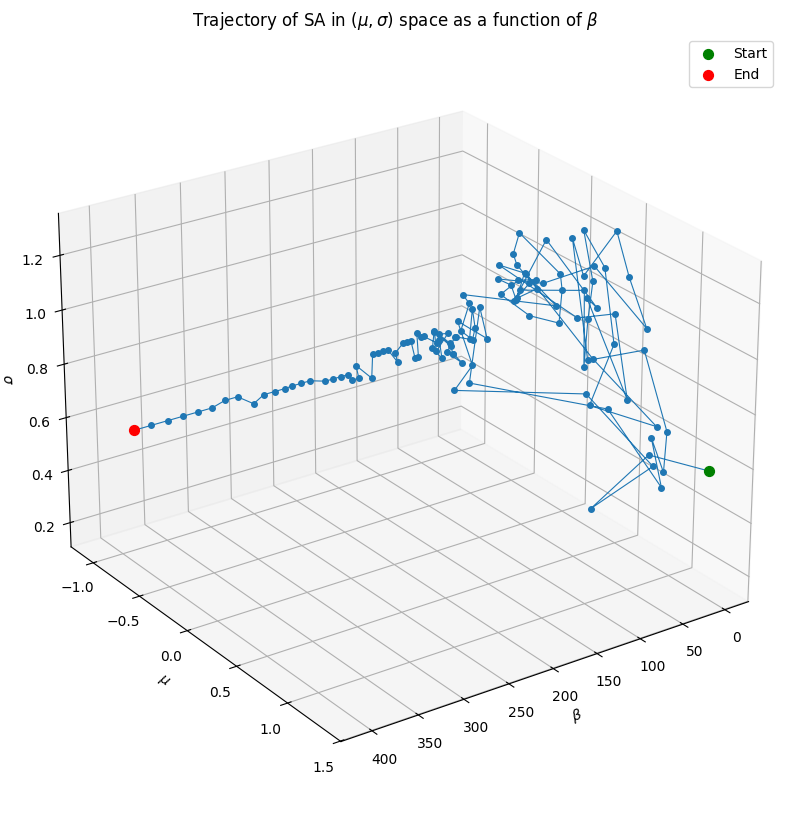

In [4]:
# Create a three-dimensional plot of the Simulated Annealing trajectory
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection="3d")

# Load the variational parameters and the inverse temperature beta
mu, sigma, beta= np.loadtxt("Output/risultati_SA.txt", usecols=(3,4,5), unpack=True)

# Plot the sequence of parameter configurations explored during the optimization
ax.plot(beta, mu, sigma, "-o", markersize = 4, linewidth=0.8) 

# Highlight the initial and final points of the annealing trajectory
ax.scatter(beta[0], mu[0], sigma[0], s=50, color="green", label="Start", zorder=3)
ax.scatter(beta[-1], mu[-1], sigma[-1], s=50, color="red", label="End", zorder=3)
ax.set_xlabel(r'$\beta$') 
ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'$\sigma$')
ax.set_title(r"Trajectory of SA in $(\mu,\sigma)$ space as a function of $\beta$")
ax.legend()
ax.grid(True)
ax.view_init(elev=25, azim=55)

plt.show()


A questo punto viene ripetuto quanto eseguito nell'esercizio `08.1` ma con i parametri $(\mu, \sigma)$ ottimizzati.
Anche in questo caso prima della simulazione viene equilibrato il sistema per $20000$ steps Monte Carlo.

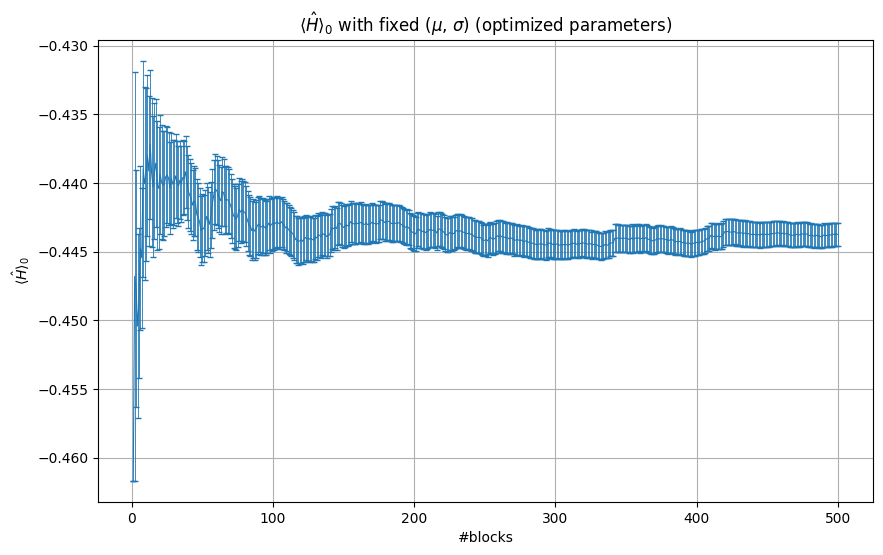

<H>_0 = -0.443739 ± 0.000844



In [5]:
# Plot the progressive ground-state energy estimate using the optimized parameters
plot("Output/E_after_SA.txt", '#blocks', r'$\langle \hat{H} \rangle_0$', r'$\langle \hat{H} \rangle_0$ with fixed ($\mu$, $\sigma$) (optimized parameters)', "C0", 0.8)

# Load the progressive energy estimate and its statistical uncertainty
E, errore = np.loadtxt("Output/E_after_SA.txt", usecols= (1,2), unpack= True)

# Print the final estimate obtained from the last block
print(f"<H>_0 = {E[-1]:.6f} ± {errore[-1]:.6f}\n")


Infine si realizza un istogramma delle posizioni $x$ campionate con Metropolis considerando i parametri variazionali ottimizzati in modo tale da ottenere una stima dell'andamento di $|\Psi_T^{\sigma,\mu}(x)|^2$ ricavata dalla simulazione eseguita. Tale andamento viene confrontato con l'andamento analitico di $|\Psi_T^{\sigma,\mu}(x)|^2$ (ricavato utilizzando l'espressione teorica della funzione d'onda $\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+e^{-\frac{(x+\mu)^2}{2\sigma^2}}$) e con la soluzione numerica ottenuta trasformando l'equazione di Schrodinger in una equazione matriciale.
Sia l'istogramma che le due curve sono opportunamente normalizzate.

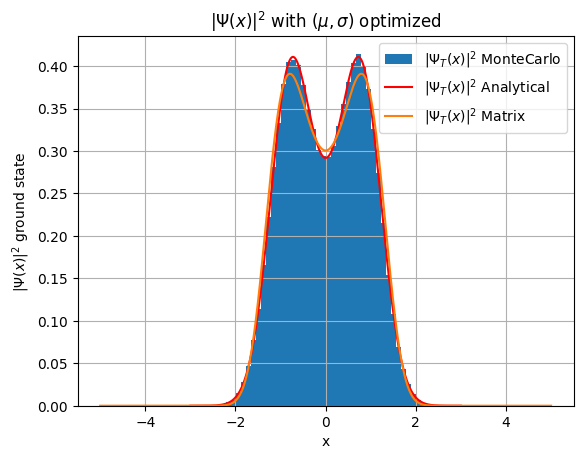

In [12]:
# Load the positions sampled by the Metropolis algorithm
x = np.loadtxt("Output/x_sampled.txt")

# Build the normalized histogram representing the sampled probability density
n_bins = 50
n, bins, patches = plt.hist(x, n_bins, density=True, label= "$|\Psi_T(x)|^2$ MonteCarlo")

# Define the spatial grid used to evaluate the analytical trial probability density
x_teorico = np.linspace(-3, 3, 500)

# Read the optimized variational parameters from the final Simulated Annealing step
mu, sigma = np.loadtxt("Output/risultati_SA.txt", usecols=(3, 4))[-1]

# Evaluate the squared trial wave function with the optimized parameters
pdf = (np.exp(-(x_teorico-mu)**2/(2*sigma**2))+ np.exp(-(x_teorico+mu)**2/(2*sigma**2)))**2

# Normalize the analytical probability density to unit area
pdf = pdf / np.trapz(pdf, x_teorico)
plt.plot(x_teorico, pdf, color = "red", label="$|\Psi_T(x)|^2$ Analytical")

# Define the one-dimensional double-well potential
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1

# Define the spatial interval and the number of discretization points
a = 10
N = 1000

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

plt.plot(x,(psi[0])**2, label= "$|\Psi_T(x)|^2$ Matrix")

plt.xlabel('x')
plt.ylabel('$|\Psi(x)|^2$ ground state')
plt.title ('$|\Psi(x)|^2$ with $(\mu, \sigma)$ optimized')
plt.legend()
plt.grid(True)
plt.show()